In [11]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [44]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from skimage.feature import local_binary_pattern
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# Define base path and data directories
base_path = '/content/drive/MyDrive/ComVi/ACDC'
train_data_dir = os.path.join(base_path, 'train')
test_data_dir = os.path.join(base_path, 'test')

# Check and list the contents of the train and test directories
print("\nTrain directory contents:")
print(os.listdir(train_data_dir))

print("\nTest directory contents:")
print(os.listdir(test_data_dir))



Train directory contents:
['clear_05.png', 'clear_02.png', 'clear_06.png', 'clear_01.png', 'clear_03.png', 'clear_04.png', 'clear_103.png', 'clear_105.png', 'clear_106.png', 'clear_116.png', 'clear_07.png', 'clear_102.png', 'clear_10.png', 'clear_112.png', 'clear_107.png', 'clear_110.png', 'clear_11.png', 'clear_108.png', 'clear_104.png', 'clear_100.png', 'clear_109.png', 'clear_115.png', 'clear_09.png', 'clear_111.png', 'clear_117.png', 'clear_114.png', 'clear_101.png', 'clear_08.png', 'clear_113.png', 'clear_12.png', 'clear_126.png', 'clear_137.png', 'clear_131.png', 'clear_124.png', 'clear_132.png', 'clear_119.png', 'clear_127.png', 'clear_135.png', 'clear_129.png', 'clear_125.png', 'clear_118.png', 'clear_134.png', 'clear_136.png', 'clear_123.png', 'clear_138.png', 'clear_120.png', 'clear_130.png', 'clear_122.png', 'clear_14.png', 'clear_133.png', 'clear_140.png', 'clear_13.png', 'clear_128.png', 'clear_121.png', 'clear_139.png', 'clear_142.png', 'clear_145.png', 'clear_147.png', 

In [48]:
# Function to load and preprocess the data
def load_and_preprocess_data(data_dir, img_size=(150, 150)):
    data = []  # Features of images
    labels = []  # Corresponding labels
    image_names = []  # Names of processed images

    # Mapping of filename labels to predefined weather classes
    class_mapping = {'clear': 'Clear', 'fog': 'Fog', 'night': 'Night', 'rain': 'Rain', 'snow': 'Snow'}

    for img_file in os.listdir(data_dir):
        img_path = os.path.join(data_dir, img_file)
        img = cv2.imread(img_path)

        if img is not None:
            img = cv2.resize(img, img_size)
            features = extract_features(img)
            label = get_label_from_filename(img_file)

            if label in class_mapping:
                data.append(features)
                labels.append(class_mapping[label])
                image_names.append(img_file)

    return np.array(data), np.array(labels), image_names

# Function to extract features from an image
def extract_features(img):
    hist_features = cv2.calcHist([img], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256]).flatten()
    avg_color_features = [np.mean(img[:,:,0]), np.mean(img[:,:,1]), np.mean(img[:,:,2])]
    std_color_features = [np.std(img[:,:,0]), np.std(img[:,:,1]), np.std(img[:,:,2])]
    moments_features = [cv2.moments(img[:,:,0])['m00'], cv2.moments(img[:,:,1])['m00'], cv2.moments(img[:,:,2])['m00']]

    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray_img, P=8, R=1, method='uniform')
    lbp_hist = np.histogram(lbp, bins=np.arange(0, 10), range=(0, 9))[0]

    return np.concatenate((hist_features, avg_color_features, std_color_features, moments_features, lbp_hist))

# Function to get label from filename
def get_label_from_filename(filename):
    return filename.split('_')[0].lower()

# Function to save data to Excel
def save_to_excel(data, labels, image_names, file_name):
    df = pd.DataFrame(data, columns=[f"Feature_{i}" for i in range(data.shape[1])])
    df['Label'] = labels
    df['Image_Name'] = image_names
    df.to_excel(file_name, index=False)


In [49]:
# Load and preprocess the training data
train_data, train_labels, train_image_names = load_and_preprocess_data(train_data_dir)
save_to_excel(train_data, train_labels, train_image_names, 'train_data_features.xlsx')


In [50]:
# Train the Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(train_data, train_labels)


RandomForestClassifier(random_state=42)

In [51]:
# Load and preprocess the test data
test_data, test_labels, test_image_names = load_and_preprocess_data(test_data_dir)
save_to_excel(test_data, test_labels, test_image_names, 'test_data_features.xlsx')


Accuracy: 0.96
Classification Report:
               precision    recall  f1-score   support

       Clear       1.00      1.00      1.00       100
         Fog       0.94      0.94      0.94       100
       Night       1.00      0.99      0.99       100
        Rain       0.93      0.98      0.96       100
        Snow       0.93      0.89      0.91       100

    accuracy                           0.96       500
   macro avg       0.96      0.96      0.96       500
weighted avg       0.96      0.96      0.96       500



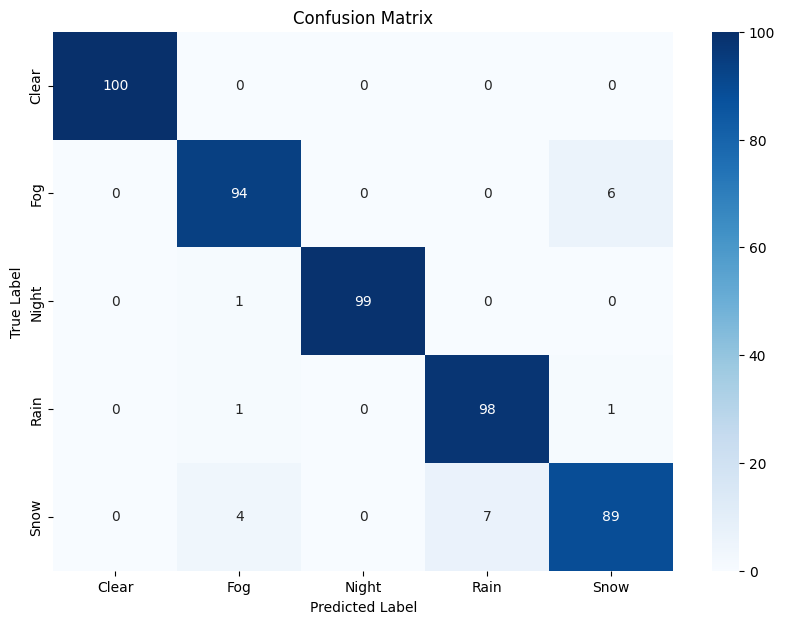

In [52]:
# Predict classes for the test set
predicted_labels = clf.predict(test_data)

# Evaluate the classifier
accuracy = accuracy_score(test_labels, predicted_labels)
classification_report_str = classification_report(test_labels, predicted_labels)
print(f"Accuracy: {accuracy}")
print("Classification Report:\n", classification_report_str)

# Confusion Matrix
conf_matrix = confusion_matrix(test_labels, predicted_labels, labels=['Clear', 'Fog', 'Night', 'Rain', 'Snow'])

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Clear', 'Fog', 'Night', 'Rain', 'Snow'], yticklabels=['Clear', 'Fog', 'Night', 'Rain', 'Snow'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


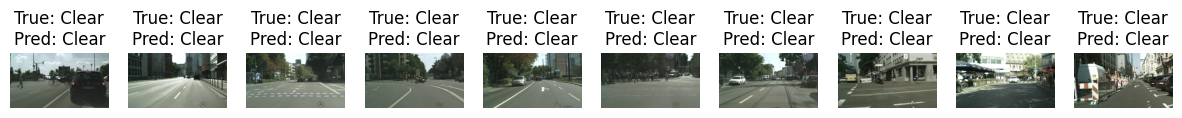

In [53]:
# Function to visualize sample images with their true and predicted labels
def visualize_samples(data_dir, image_names, true_labels, predicted_labels, num_samples=10):
    plt.figure(figsize=(15, 10))
    for i in range(min(num_samples, len(image_names))):
        img_path = os.path.join(data_dir, image_names[i])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"True: {true_labels[i]}\nPred: {predicted_labels[i]}")
        plt.axis('off')
    plt.show()

# Visualize some sample test images with predictions
visualize_samples(test_data_dir, test_image_names, test_labels, predicted_labels)


Predicted Weather Condition: Clear


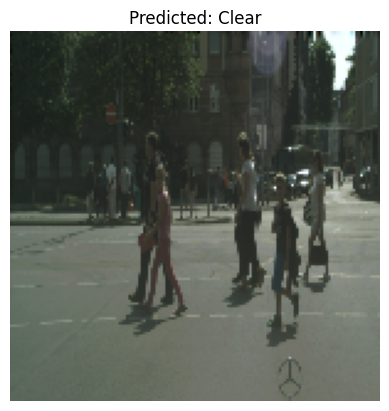

In [54]:
# Predict the weather condition for a random photo
random_photo_path = os.path.join(test_data_dir, "clear_61.png")
random_photo = cv2.imread(random_photo_path)
random_photo = cv2.resize(random_photo, (150, 150))
random_photo_features = extract_features(random_photo)
predicted_condition = clf.predict([random_photo_features])[0]
print(f"Predicted Weather Condition: {predicted_condition}")

# Display the random photo
random_photo_rgb = cv2.cvtColor(random_photo, cv2.COLOR_BGR2RGB)
plt.imshow(random_photo_rgb)
plt.title(f"Predicted: {predicted_condition}")
plt.axis('off')
plt.show()


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

In [61]:
# Define the CNN architecture
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(64 * 37 * 37, 128)
        self.fc2 = nn.Linear(128, 5)  # 5 classes: Clear, Fog, Night, Rain, Snow
        self.relu = nn.ReLU()
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 37 * 37)
        x = self.relu(self.fc1(x))
        x = self.softmax(self.fc2(x))
        return x


In [62]:
# Define transformations for preprocessing
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
])

In [63]:
# Load dataset (train and test datasets in the new organized directories)
train_dataset = datasets.ImageFolder(root=train_copy_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_copy_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [64]:
# Create model instance, loss function and optimizer
model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [65]:
# Variables to store results for visualization
train_losses = []
test_accuracies = []

# Train the CNN
num_epochs = 30
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Test Accuracy Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_train_loss:.4f}, Test Accuracy: {accuracy:.2f}%")

print("Training Complete!")

Epoch [1/30], Loss: 0.9684, Test Accuracy: 78.00%
Epoch [2/30], Loss: 0.2751, Test Accuracy: 87.80%
Epoch [3/30], Loss: 0.2007, Test Accuracy: 90.60%
Epoch [4/30], Loss: 0.1242, Test Accuracy: 89.40%
Epoch [5/30], Loss: 0.0961, Test Accuracy: 89.80%
Epoch [6/30], Loss: 0.0561, Test Accuracy: 90.40%
Epoch [7/30], Loss: 0.0293, Test Accuracy: 91.80%
Epoch [8/30], Loss: 0.0088, Test Accuracy: 93.40%
Epoch [9/30], Loss: 0.0041, Test Accuracy: 94.80%
Epoch [10/30], Loss: 0.0037, Test Accuracy: 93.60%
Epoch [11/30], Loss: 0.0020, Test Accuracy: 93.40%
Epoch [12/30], Loss: 0.0014, Test Accuracy: 93.00%
Epoch [13/30], Loss: 0.0030, Test Accuracy: 92.60%
Epoch [14/30], Loss: 0.0014, Test Accuracy: 93.00%
Epoch [15/30], Loss: 0.0007, Test Accuracy: 93.20%
Epoch [16/30], Loss: 0.0005, Test Accuracy: 93.40%
Epoch [17/30], Loss: 0.0006, Test Accuracy: 93.00%
Epoch [18/30], Loss: 0.0004, Test Accuracy: 93.20%
Epoch [19/30], Loss: 0.0003, Test Accuracy: 93.20%
Epoch [20/30], Loss: 0.0003, Test Accura

In [66]:
# Save the model's state dictionary
save_path = '/content/drive/MyDrive/ComVi/model.pth'
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")


Model saved to /content/drive/MyDrive/ComVi/model.pth


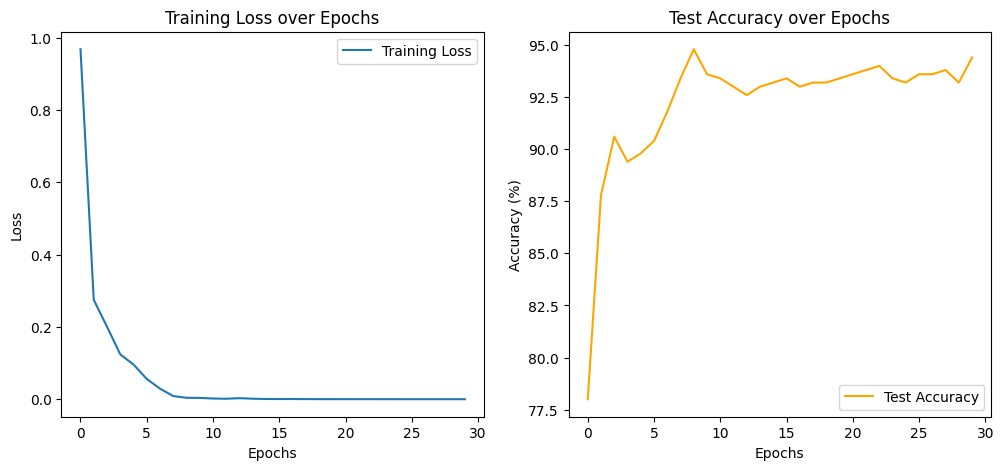

In [67]:
# Plot the training loss and test accuracy over epochs
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy', color='orange')
plt.title('Test Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

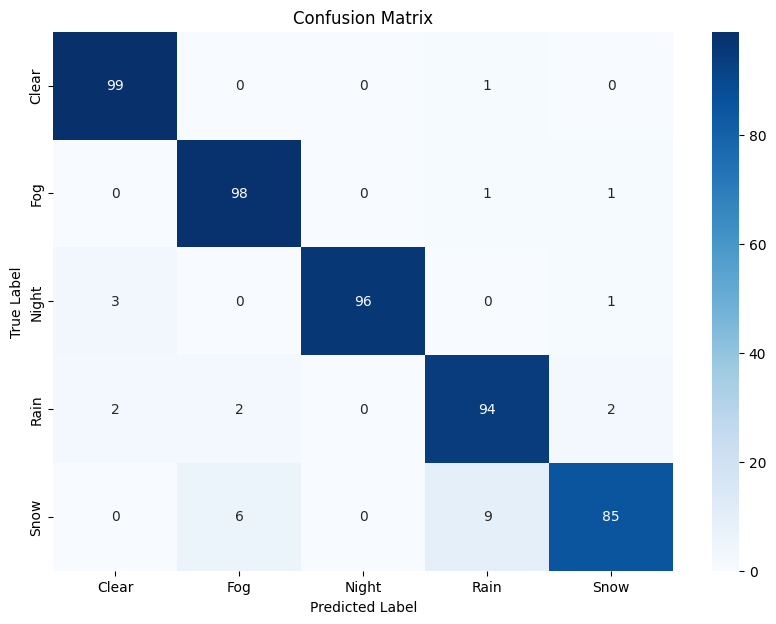

Classification Report:
               precision    recall  f1-score   support

       Clear       0.95      0.99      0.97       100
         Fog       0.92      0.98      0.95       100
       Night       1.00      0.96      0.98       100
        Rain       0.90      0.94      0.92       100
        Snow       0.96      0.85      0.90       100

    accuracy                           0.94       500
   macro avg       0.95      0.94      0.94       500
weighted avg       0.95      0.94      0.94       500



In [68]:
# Evaluate the final model and generate confusion matrix & classification report
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
class_names = ['Clear', 'Fog', 'Night', 'Rain', 'Snow']

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification report
print("Classification Report:\n", classification_report(all_labels, all_preds, target_names=class_names))

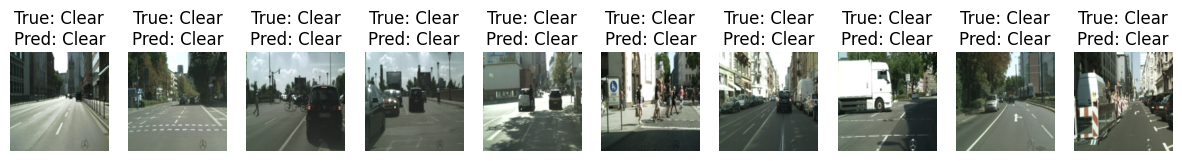

In [69]:
# Visualize some sample test images with predictions
def visualize_samples(data_loader, model, class_names, num_samples=10):
    model.eval()
    data_iter = iter(data_loader)
    images, labels = next(data_iter)
    images = images[:num_samples]
    labels = labels[:num_samples]

    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    plt.figure(figsize=(15, 10))
    for i in range(num_samples):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = img / img.max()  # Normalize to [0,1] for display
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
        plt.axis('off')
    plt.show()

# Visualize a few predictions
visualize_samples(test_loader, model, class_names)



In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

In [35]:
# Define the ResNet-18 architecture
class ResNet18(nn.Module):
    def __init__(self, num_classes=5):
        super(ResNet18, self).__init__()
        # Load a pre-trained ResNet-18 model
        self.resnet = models.resnet18(pretrained=True)
        # Modify the final fully connected layer
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, num_classes)

    def forward(self, x):
        return self.resnet(x)


In [36]:
# Define transformations for preprocessing
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
])


In [37]:
# Load dataset (train and test datasets in the new organized directories)
train_dataset = datasets.ImageFolder(root=train_copy_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_copy_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [39]:
# Create model instance, loss function, and optimizer
model = ResNet18(num_classes=5)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Variables to store results for visualization
train_losses = []
test_accuracies = []

# Train the ResNet-18
num_epochs = 30
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Test Accuracy Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_train_loss:.4f}, Test Accuracy: {accuracy:.2f}%")

print("Training Complete!")

Epoch [1/30], Loss: 0.3002, Test Accuracy: 73.00%
Epoch [2/30], Loss: 0.0806, Test Accuracy: 91.40%
Epoch [3/30], Loss: 0.0536, Test Accuracy: 95.20%
Epoch [4/30], Loss: 0.0266, Test Accuracy: 88.20%
Epoch [5/30], Loss: 0.0931, Test Accuracy: 91.80%
Epoch [6/30], Loss: 0.0627, Test Accuracy: 92.00%
Epoch [7/30], Loss: 0.0109, Test Accuracy: 98.00%
Epoch [8/30], Loss: 0.0046, Test Accuracy: 99.00%
Epoch [9/30], Loss: 0.0034, Test Accuracy: 98.60%
Epoch [10/30], Loss: 0.0157, Test Accuracy: 78.20%
Epoch [11/30], Loss: 0.1155, Test Accuracy: 51.60%
Epoch [12/30], Loss: 0.1696, Test Accuracy: 55.60%
Epoch [13/30], Loss: 0.1024, Test Accuracy: 96.20%
Epoch [14/30], Loss: 0.0454, Test Accuracy: 92.40%
Epoch [15/30], Loss: 0.0300, Test Accuracy: 97.40%
Epoch [16/30], Loss: 0.0152, Test Accuracy: 95.40%
Epoch [17/30], Loss: 0.0310, Test Accuracy: 96.00%
Epoch [18/30], Loss: 0.0428, Test Accuracy: 95.20%
Epoch [19/30], Loss: 0.0241, Test Accuracy: 97.40%
Epoch [20/30], Loss: 0.0101, Test Accura

In [40]:
# Save the model's state dictionary
save_path = '/content/drive/MyDrive/ComVi/modelResNet.pth'
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")


Model saved to /content/drive/MyDrive/ComVi/modelResNet.pth


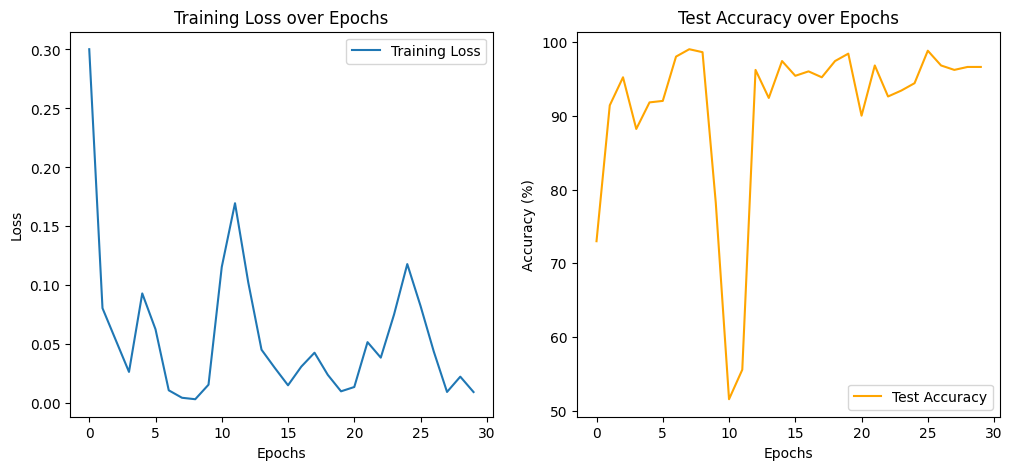

In [41]:
# Plot the training loss and test accuracy over epochs
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy', color='orange')
plt.title('Test Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

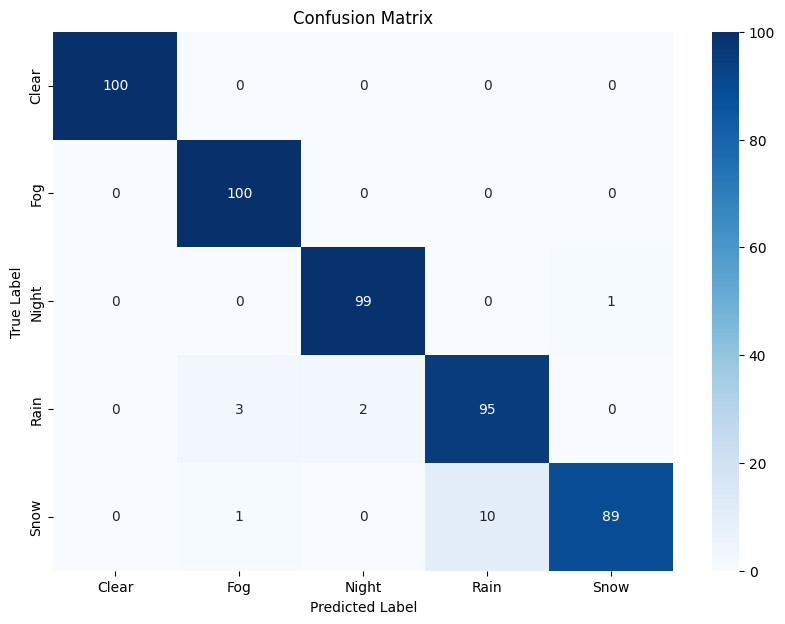

Classification Report:
               precision    recall  f1-score   support

       Clear       1.00      1.00      1.00       100
         Fog       0.96      1.00      0.98       100
       Night       0.98      0.99      0.99       100
        Rain       0.90      0.95      0.93       100
        Snow       0.99      0.89      0.94       100

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500



In [42]:
# Evaluate the final model and generate confusion matrix & classification report
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
class_names = ['Clear', 'Fog', 'Night', 'Rain', 'Snow']

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification report
print("Classification Report:\n", classification_report(all_labels, all_preds, target_names=class_names))

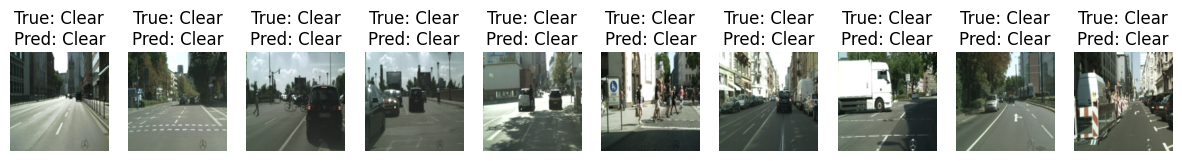

In [55]:
def visualize_samples(data_loader, model, num_samples=10):
    model.eval()  # Set the model to evaluation mode
    data_iter = iter(data_loader)  # Create an iterator from the data loader
    images, labels = next(data_iter)  # Use next() to get the next batch of data
    images = images[:num_samples]  # Select the number of samples to visualize
    labels = labels[:num_samples]

    with torch.no_grad():  # Disable gradient computation
        outputs = model(images)  # Get model predictions
        _, preds = torch.max(outputs, 1)  # Get the predicted class indices

    plt.figure(figsize=(15, 10))  # Create a figure for plotting
    for i in range(num_samples):
        img = images[i].permute(1, 2, 0).cpu().numpy()  # Convert tensor to numpy array
        img = img / img.max()  # Normalize to [0, 1] for display
        plt.subplot(1, num_samples, i + 1)  # Create a subplot for each sample
        plt.imshow(img)  # Display the image
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")  # Set the title
        plt.axis('off')  # Hide the axis

    plt.show()  # Show the plot

# Visualize a few predictions
visualize_samples(test_loader, model)
